# 22 — Functional SVM: results & kernel comparison

Loads outputs from **`21_functional_svm.py`** (`results/functional_svm/`).

**Sections:**
1. Summary tables (4 functional kernels)
2. Per-fold metric distributions by kernel
3. Kernel comparison bar chart (PR-AUC / ROC-AUC)
4. Hyperparameter analysis (C, γ, support vectors)
5. Cross-experiment comparison with polynomial / FPCA / ROCKET / Functional LR baselines
6. Statistical significance tests (paired t-test between kernels)

**Run first:** `python 21_functional_svm.py` (from `transformation_experiment/`)

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats as sp_stats

EXPERIMENT_DIR = Path.cwd() if Path("data").exists() else Path("transformation_experiment")
DATA_DIR = EXPERIMENT_DIR / "data"
RESULTS_DIR = EXPERIMENT_DIR / "results"
FSVM_DIR = RESULTS_DIR / "functional_svm"
POC_DIR = Path("transformation_poc") if Path("transformation_poc").exists() else Path("..") / "transformation_poc"

print(f"Results dir: {FSVM_DIR.resolve()}")

Results dir: /Users/erikak/Documents/uni/bakalauras/kodas/transformation_experiment/results/functional_svm


## 1. Summary tables

In [12]:
df = pd.read_csv(FSVM_DIR / "functional_svm_rskf_metrics.csv")
print(f"Loaded {len(df)} rows ({df['kernel_name'].nunique()} kernels x {df['split'].nunique()} folds)")

KERNEL_ORDER = ["L2_linear", "L2_rbf", "deriv1_rbf", "sobolev_rbf"]
KERNEL_LABELS = {
    "L2_linear": "L2 Linear",
    "L2_rbf": "L2 RBF",
    "deriv1_rbf": "1st-Derivative RBF",
    "sobolev_rbf": "Sobolev RBF",
}

metric_cols = ["roc_auc", "pr_auc", "f1", "sensitivity", "specificity",
               "precision", "youden_j"]

for kname in KERNEL_ORDER:
    sub = df[df["kernel_name"] == kname]
    print(f"\n{KERNEL_LABELS[kname]}  (n={len(sub)} folds)")
    for col in metric_cols:
        print(f"  {col:20s}: {sub[col].mean():.4f} +/- {sub[col].std():.4f}")

Loaded 200 rows (4 kernels x 50 folds)

L2 Linear  (n=50 folds)
  roc_auc             : 0.9130 +/- 0.0194
  pr_auc              : 0.8648 +/- 0.0270
  f1                  : 0.8130 +/- 0.0267
  sensitivity         : 0.8285 +/- 0.0316
  specificity         : 0.9480 +/- 0.0127
  precision           : 0.7994 +/- 0.0400
  youden_j            : 0.7765 +/- 0.0332

L2 RBF  (n=50 folds)
  roc_auc             : 0.9275 +/- 0.0167
  pr_auc              : 0.8787 +/- 0.0263
  f1                  : 0.8002 +/- 0.0372
  sensitivity         : 0.8407 +/- 0.0327
  specificity         : 0.9348 +/- 0.0234
  precision           : 0.7664 +/- 0.0613
  youden_j            : 0.7755 +/- 0.0374

1st-Derivative RBF  (n=50 folds)
  roc_auc             : 0.8350 +/- 0.0303
  pr_auc              : 0.6896 +/- 0.0553
  f1                  : 0.6324 +/- 0.0419
  sensitivity         : 0.7015 +/- 0.0451
  specificity         : 0.8714 +/- 0.0272
  precision           : 0.5781 +/- 0.0538
  youden_j            : 0.5728 +/- 0.052

## 2. Per-fold metric distributions by kernel

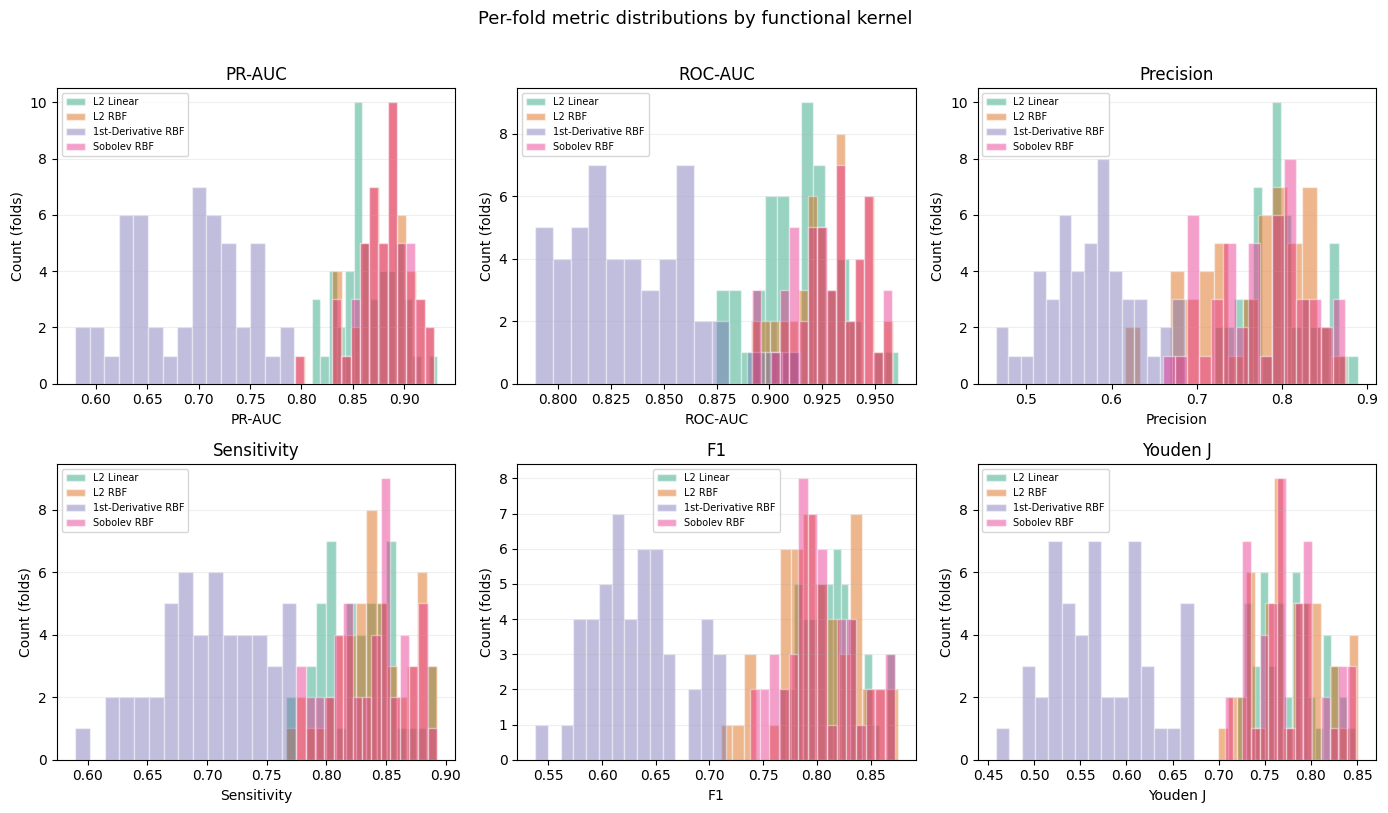

In [13]:
KERNEL_COLORS = {
    "L2_linear": "#1b9e77",
    "L2_rbf": "#d95f02",
    "deriv1_rbf": "#7570b3",
    "sobolev_rbf": "#e7298a",
}

hist_metrics = [
    ("pr_auc", "PR-AUC"),
    ("roc_auc", "ROC-AUC"),
    ("precision", "Precision"),
    ("sensitivity", "Sensitivity"),
    ("f1", "F1"),
    ("youden_j", "Youden J"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, (col, label) in zip(axes, hist_metrics):
    for kname in KERNEL_ORDER:
        sub = df[df["kernel_name"] == kname]
        ax.hist(sub[col].dropna(), bins=15, color=KERNEL_COLORS[kname],
                edgecolor="white", alpha=0.45, label=KERNEL_LABELS[kname])
    ax.set_xlabel(label)
    ax.set_ylabel("Count (folds)")
    ax.set_title(label)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2, axis="y")

fig.suptitle("Per-fold metric distributions by functional kernel", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 3. Kernel comparison bar chart

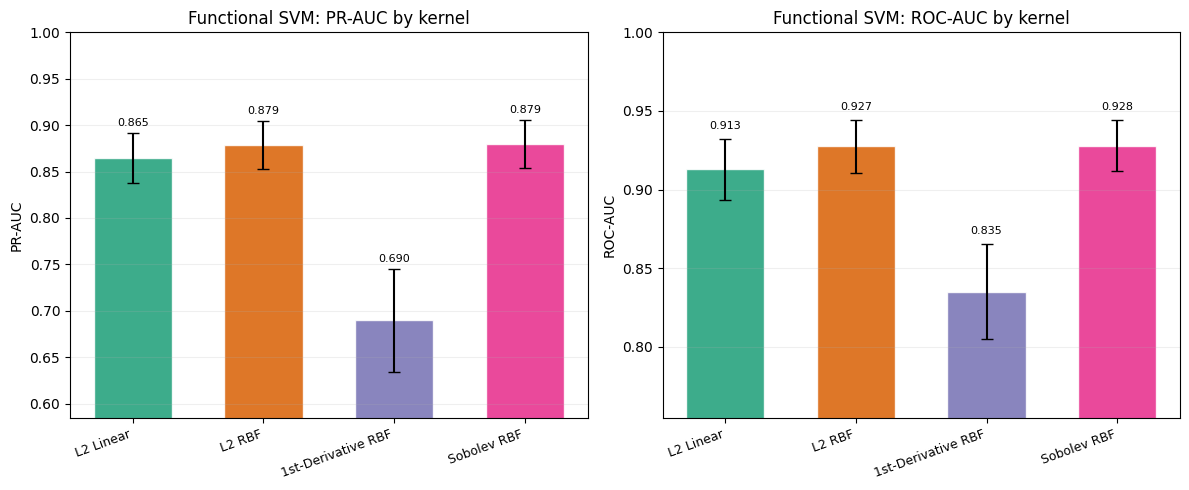

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric, ylabel in [
    (axes[0], "pr_auc", "PR-AUC"),
    (axes[1], "roc_auc", "ROC-AUC"),
]:
    means, stds, colors, labels = [], [], [], []
    for kname in KERNEL_ORDER:
        sub = df[df["kernel_name"] == kname]
        means.append(sub[metric].mean())
        stds.append(sub[metric].std())
        colors.append(KERNEL_COLORS[kname])
        labels.append(KERNEL_LABELS[kname])

    x = np.arange(len(KERNEL_ORDER))
    bars = ax.bar(x, means, yerr=stds, capsize=4, color=colors, edgecolor="white",
                  alpha=0.85, width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(f"Functional SVM: {ylabel} by kernel")
    ax.grid(True, alpha=0.2, axis="y")

    # Annotate values
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(i, m + s + 0.005, f"{m:.3f}", ha="center", va="bottom", fontsize=8)

    # Set y range to focus on differences
    ymin = min(means) - max(stds) - 0.05
    ax.set_ylim(max(0, ymin), 1.0)

fig.tight_layout()
plt.show()

## 4. Hyperparameter analysis

Distribution of selected C, γ, and number of support vectors across folds.

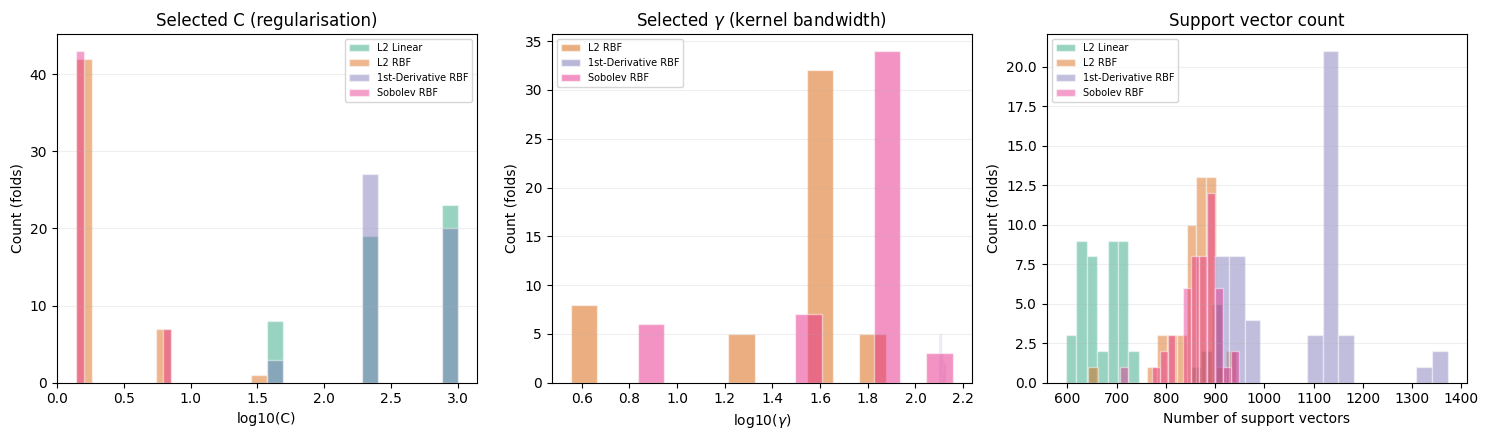

Hyperparameter summary:
  L2 Linear             : C_median=193, nSV=705/50*~2252
  L2 RBF                : C_median=1.39, gamma_median=36.42, nSV=859/50*~2252
  1st-Derivative RBF    : C_median=193, gamma_median=128.62, nSV=1069/50*~2252
  Sobolev RBF           : C_median=1.39, gamma_median=69.52, nSV=868/50*~2252


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# C distribution
ax = axes[0]
for kname in KERNEL_ORDER:
    sub = df[df["kernel_name"] == kname]
    ax.hist(np.log10(sub["best_C"]), bins=12, color=KERNEL_COLORS[kname],
            alpha=0.45, edgecolor="white", label=KERNEL_LABELS[kname])
ax.set_xlabel("log10(C)")
ax.set_ylabel("Count (folds)")
ax.set_title("Selected C (regularisation)")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.2, axis="y")

# gamma distribution (RBF kernels only)
ax = axes[1]
rbf_kernels = ["L2_rbf", "deriv1_rbf", "sobolev_rbf"]
for kname in rbf_kernels:
    sub = df[df["kernel_name"] == kname]
    gamma_vals = sub["best_gamma"].dropna()
    if len(gamma_vals) > 0:
        ax.hist(np.log10(gamma_vals), bins=12, color=KERNEL_COLORS[kname],
                alpha=0.5, edgecolor="white", label=KERNEL_LABELS[kname])
ax.set_xlabel(r"log10($\gamma$)")
ax.set_ylabel("Count (folds)")
ax.set_title(r"Selected $\gamma$ (kernel bandwidth)")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.2, axis="y")

# Support vectors
ax = axes[2]
for kname in KERNEL_ORDER:
    sub = df[df["kernel_name"] == kname]
    ax.hist(sub["n_support_vectors"], bins=15, color=KERNEL_COLORS[kname],
            alpha=0.45, edgecolor="white", label=KERNEL_LABELS[kname])
ax.set_xlabel("Number of support vectors")
ax.set_ylabel("Count (folds)")
ax.set_title("Support vector count")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.2, axis="y")

fig.tight_layout()
plt.show()

# Print summary
print("Hyperparameter summary:")
for kname in KERNEL_ORDER:
    sub = df[df["kernel_name"] == kname]
    c_med = sub["best_C"].median()
    nsv_mean = sub["n_support_vectors"].mean()
    gamma_str = ""
    if kname != "L2_linear":
        gamma_str = f", gamma_median={sub['best_gamma'].median():.2f}"
    print(f"  {KERNEL_LABELS[kname]:22s}: C_median={c_med:.3g}{gamma_str}, "
          f"nSV={nsv_mean:.0f}/{len(sub)}*~2252")

## 5. Cross-experiment comparison

Compare functional SVM kernels against polynomial baselines, FPCA, ROCKET, and functional logistic regression.

In [16]:
def fmt(mean, std):
    return f"{mean:.4f} +/- {std:.4f}"

comp_rows = []

# Functional SVM (this experiment) — all kernels
for kname in KERNEL_ORDER:
    sub = df[df["kernel_name"] == kname]
    comp_rows.append({
        "Method": f"Func. SVM ({KERNEL_LABELS[kname]})",
        "Representation": "343-d L2 spectra (func. kernel)",
        "Dim": 343,
        "PR-AUC": fmt(sub["pr_auc"].mean(), sub["pr_auc"].std()),
        "ROC-AUC": fmt(sub["roc_auc"].mean(), sub["roc_auc"].std()),
        "F1": fmt(sub["f1"].mean(), sub["f1"].std()),
        "Precision": fmt(sub["precision"].mean(), sub["precision"].std()),
        "Sensitivity": fmt(sub["sensitivity"].mean(), sub["sensitivity"].std()),
        "pr_auc_mean": sub["pr_auc"].mean(),  # for sorting
    })

# Functional LR
flogreg_path = RESULTS_DIR / "functional_logreg" / "functional_logreg_results.csv"
if flogreg_path.exists():
    df_flr = pd.read_csv(flogreg_path)
    for pname in ["L2_ridge", "L1_lasso"]:
        sub = df_flr[df_flr["penalty_name"] == pname]
        if sub.empty:
            continue
        comp_rows.append({
            "Method": f"Functional LR ({pname})",
            "Representation": "343-d L2 spectra",
            "Dim": 343,
            "PR-AUC": fmt(sub["pr_auc"].mean(), sub["pr_auc"].std()),
            "ROC-AUC": fmt(sub["roc_auc"].mean(), sub["roc_auc"].std()),
            "F1": fmt(sub["f1"].mean(), sub["f1"].std()),
            "Precision": fmt(sub["precision"].mean(), sub["precision"].std()),
            "Sensitivity": fmt(sub["sensitivity"].mean(), sub["sensitivity"].std()),
            "pr_auc_mean": sub["pr_auc"].mean(),
        })

# Polynomial baselines (focused experiment)
focused_path = RESULTS_DIR / "focused_summary.csv"
if focused_path.exists():
    df_base = pd.read_csv(focused_path)

    def best_row(mask):
        return df_base.loc[mask].sort_values("pr_auc_mean", ascending=False).iloc[0]

    # XP 110
    r = best_row((df_base["representation"] == "og_xp_110") & (df_base["classifier"] == "SVM_RBF"))
    comp_rows.append({
        "Method": "XP 110-d + SVM RBF",
        "Representation": "Native Hermite coeffs",
        "Dim": 110,
        "PR-AUC": fmt(r["pr_auc_mean"], r["pr_auc_std"]),
        "ROC-AUC": fmt(r["roc_auc_mean"], r["roc_auc_std"]),
        "F1": fmt(r["f1_mean"], r["f1_std"]),
        "Precision": fmt(r["precision_mean"], r["precision_std"]),
        "Sensitivity": fmt(r["sensitivity_mean"], r["sensitivity_std"]),
        "pr_auc_mean": r["pr_auc_mean"],
    })

    # Best Chebyshev + SVM
    ch_mask = (df_base["representation"].str.startswith("chebyshev")
               & df_base["representation"].str.endswith("_L2")
               & (df_base["classifier"] == "SVM_RBF"))
    if ch_mask.any():
        r = best_row(ch_mask)
        comp_rows.append({
            "Method": f"Chebyshev L2 + SVM (K={int(r['n_features'])})",
            "Representation": "Polynomial coeffs",
            "Dim": int(r["n_features"]),
            "PR-AUC": fmt(r["pr_auc_mean"], r["pr_auc_std"]),
            "ROC-AUC": fmt(r["roc_auc_mean"], r["roc_auc_std"]),
            "F1": fmt(r["f1_mean"], r["f1_std"]),
            "Precision": fmt(r["precision_mean"], r["precision_std"]),
            "Sensitivity": fmt(r["sensitivity_mean"], r["sensitivity_std"]),
            "pr_auc_mean": r["pr_auc_mean"],
        })

# FPCA best
fpca_path = RESULTS_DIR / "fpca_classifier_summary.csv"
if fpca_path.exists():
    df_fpca = pd.read_csv(fpca_path)
    r = df_fpca.loc[df_fpca["pr_auc_mean"].idxmax()]
    comp_rows.append({
        "Method": f"FPCA + {r['classifier'].upper()} (J={int(r['J'])})",
        "Representation": "Data-adaptive (SVD)",
        "Dim": int(r["J"]),
        "PR-AUC": fmt(r["pr_auc_mean"], r["pr_auc_std"]),
        "ROC-AUC": fmt(r["roc_auc_mean"], r["roc_auc_std"]),
        "F1": fmt(r["f1_mean"], r["f1_std"]),
        "Precision": fmt(r["precision_mean"], r["precision_std"]),
        "Sensitivity": fmt(r["sensitivity_mean"], r["sensitivity_std"]),
        "pr_auc_mean": r["pr_auc_mean"],
    })

# ROCKET best
rocket_path = RESULTS_DIR / "rocket_rskf_summary.csv"
if rocket_path.exists():
    df_rocket = pd.read_csv(rocket_path)
    r = df_rocket.loc[df_rocket["pr_auc_mean"].idxmax()]
    comp_rows.append({
        "Method": f"MiniROCKET + {r.get('classifier', 'ridge')}",
        "Representation": "Random convolutions",
        "Dim": int(r["n_kernels"]) if "n_kernels" in r.index else "?",
        "PR-AUC": fmt(r["pr_auc_mean"], r["pr_auc_std"]),
        "ROC-AUC": fmt(r["roc_auc_mean"], r["roc_auc_std"]),
        "F1": fmt(r["f1_mean"], r["f1_std"]),
        "Precision": fmt(r["precision_mean"], r["precision_std"]),
        "Sensitivity": fmt(r["sensitivity_mean"], r["sensitivity_std"]),
        "pr_auc_mean": r["pr_auc_mean"],
    })

# RKVS best
rkvs_path = RESULTS_DIR / "rkvs_rskf_summary.csv"
if rkvs_path.exists():
    df_rkvs = pd.read_csv(rkvs_path)
    r = df_rkvs.loc[df_rkvs["pr_auc_mean"].idxmax()]
    comp_rows.append({
        "Method": f"RKVS + {r['classifier']} (K={int(r['K'])})",
        "Representation": "Selected wavelengths",
        "Dim": int(r["K"]),
        "PR-AUC": fmt(r["pr_auc_mean"], r["pr_auc_std"]),
        "ROC-AUC": fmt(r["roc_auc_mean"], r["roc_auc_std"]),
        "F1": fmt(r["f1_mean"], r["f1_std"]),
        "Precision": fmt(r["precision_mean"], r["precision_std"]),
        "Sensitivity": fmt(r["sensitivity_mean"], r["sensitivity_std"]),
        "pr_auc_mean": r["pr_auc_mean"],
    })

df_comp = pd.DataFrame(comp_rows).sort_values("pr_auc_mean", ascending=False)
display(df_comp.drop(columns=["pr_auc_mean"]).reset_index(drop=True))

,Method,Representation,Dim,PR-AUC,ROC-AUC,F1,Precision,Sensitivity
0,XP 110-d + SVM RBF,Native Hermite coeffs,110,0.8805 +/- 0.0038,0.9386 +/- 0.0017,0.7995 +/- 0.0088,0.7631 +/- 0.0223,0.8419 +/- 0.0131
1,Func. SVM (Sobolev RBF),343-d L2 spectra (func. kernel),343,0.8794 +/- 0.0260,0.9279 +/- 0.0164,0.8031 +/- 0.0340,0.7741 +/- 0.0556,0.8371 +/- 0.0320
2,Func. SVM (L2 RBF),343-d L2 spectra (func. kernel),343,0.8787 +/- 0.0263,0.9275 +/- 0.0167,0.8002 +/- 0.0372,0.7664 +/- 0.0613,0.8407 +/- 0.0327
3,Chebyshev L2 + SVM (K=5),Polynomial coeffs,5,0.8750 +/- 0.0047,0.9274 +/- 0.0016,0.8112 +/- 0.0056,0.7915 +/- 0.0105,0.8335 +/- 0.0049
4,MiniROCKET + nan,Random convolutions,10000,0.8702 +/- 0.0286,0.9276 +/- 0.0165,0.7795 +/- 0.0353,0.7329 +/- 0.0495,0.8346 +/- 0.0348
5,Func. SVM (L2 Linear),343-d L2 spectra (func. kernel),343,0.8648 +/- 0.0270,0.9130 +/- 0.0194,0.8130 +/- 0.0267,0.7994 +/- 0.0400,0.8285 +/- 0.0316
6,Functional LR (L2_ridge),343-d L2 spectra,343,0.8620 +/- 0.0288,0.9141 +/- 0.0201,0.8059 +/- 0.0298,0.7843 +/- 0.0380,0.8297 +/- 0.0325
7,RKVS + lda (K=30),Selected wavelengths,30,0.8598 +/- 0.0287,0.9287 +/- 0.0134,0.7930 +/- 0.0313,0.7664 +/- 0.0514,0.8244 +/- 0.0339
8,Functional LR (L1_lasso),343-d L2 spectra,343,0.8535 +/- 0.0302,0.9112 +/- 0.0199,0.7944 +/- 0.0327,0.7622 +/- 0.0515,0.8317 +/- 0.0308
9,Func. SVM (1st-Derivative RBF),343-d L2 spectra (func. kernel),343,0.6896 +/- 0.0553,0.8350 +/- 0.0303,0.6324 +/- 0.0419,0.5781 +/- 0.0538,0.7015 +/- 0.0451


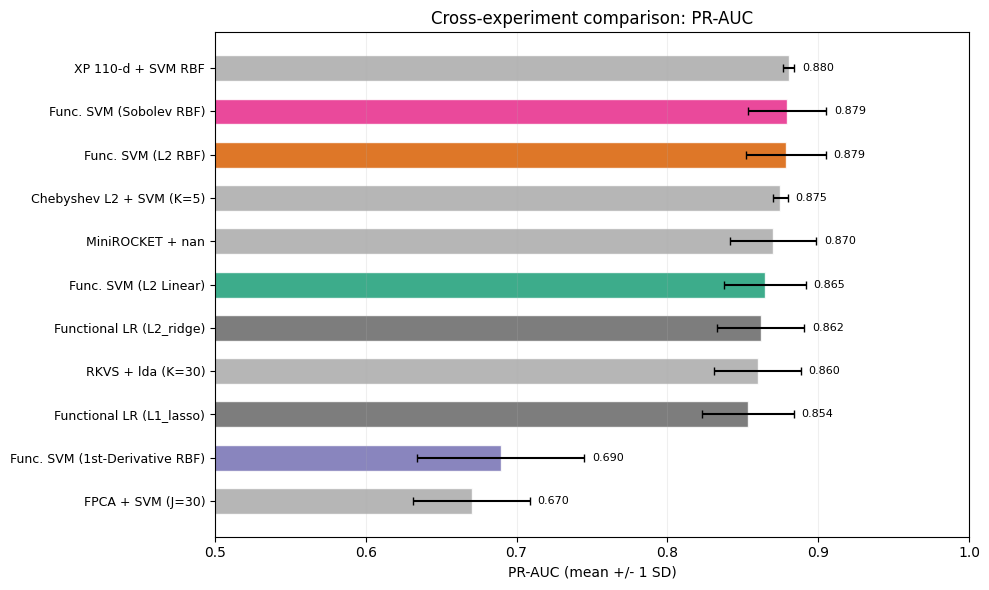

In [17]:
# Visual cross-experiment comparison (PR-AUC)
df_plot = df_comp.sort_values("pr_auc_mean", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = []
for _, r in df_plot.iterrows():
    if "Func. SVM" in r["Method"]:
        kname = [k for k in KERNEL_ORDER if KERNEL_LABELS[k] in r["Method"]][0]
        colors_bar.append(KERNEL_COLORS[kname])
    elif "Functional LR" in r["Method"]:
        colors_bar.append("#666666")
    else:
        colors_bar.append("#aaaaaa")

pr_means = [float(r["PR-AUC"].split(" +/- ")[0]) for _, r in df_plot.iterrows()]
pr_stds = [float(r["PR-AUC"].split(" +/- ")[1]) for _, r in df_plot.iterrows()]

y_pos = np.arange(len(df_plot))
ax.barh(y_pos, pr_means, xerr=pr_stds, capsize=3, color=colors_bar,
        edgecolor="white", alpha=0.85, height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot["Method"], fontsize=9)
ax.set_xlabel("PR-AUC (mean +/- 1 SD)")
ax.set_title("Cross-experiment comparison: PR-AUC")
ax.grid(True, alpha=0.2, axis="x")
ax.set_xlim(0.5, 1.0)

for i, (m, s) in enumerate(zip(pr_means, pr_stds)):
    ax.text(m + s + 0.005, i, f"{m:.3f}", va="center", fontsize=8)

fig.tight_layout()
plt.show()

## 6. Statistical significance tests

Paired t-tests between functional SVM kernels on PR-AUC (same folds, so paired comparison is valid).

In [18]:
# Paired t-tests between kernels on PR-AUC
# Since all kernels are evaluated on the same folds, paired comparison is appropriate

pivot = df.pivot_table(index="split", columns="kernel_name", values="pr_auc")

print("Paired t-tests on PR-AUC (same folds):\n")
print(f"{'Kernel A':22s} vs {'Kernel B':22s}  {'mean diff':>10s}  {'t-stat':>8s}  {'p-value':>10s}  {'sig':>4s}")
print("-" * 85)

pairs = [
    ("sobolev_rbf", "L2_rbf"),
    ("sobolev_rbf", "L2_linear"),
    ("L2_rbf", "L2_linear"),
    ("sobolev_rbf", "deriv1_rbf"),
    ("L2_rbf", "deriv1_rbf"),
    ("L2_linear", "deriv1_rbf"),
]

for a, b in pairs:
    va = pivot[a].values
    vb = pivot[b].values
    diff = va - vb
    t_stat, p_val = sp_stats.ttest_rel(va, vb)
    sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "ns"))
    print(f"{KERNEL_LABELS[a]:22s} vs {KERNEL_LABELS[b]:22s}  {diff.mean():+10.4f}  {t_stat:8.3f}  {p_val:10.2e}  {sig:>4s}")

Paired t-tests on PR-AUC (same folds):

Kernel A               vs Kernel B                 mean diff    t-stat     p-value   sig
-------------------------------------------------------------------------------------
Sobolev RBF            vs L2 RBF                     +0.0007     1.523    1.34e-01    ns
Sobolev RBF            vs L2 Linear                  +0.0146     7.372    1.76e-09   ***
L2 RBF                 vs L2 Linear                  +0.0139     6.901    9.44e-09   ***
Sobolev RBF            vs 1st-Derivative RBF         +0.1898    26.095    2.13e-30   ***
L2 RBF                 vs 1st-Derivative RBF         +0.1890    25.565    5.44e-30   ***
L2 Linear              vs 1st-Derivative RBF         +0.1752    25.197    1.05e-29   ***


## 7. Per-fold paired differences (Sobolev vs L2 RBF)

Visualise fold-level PR-AUC differences between the top two kernels to assess practical significance.

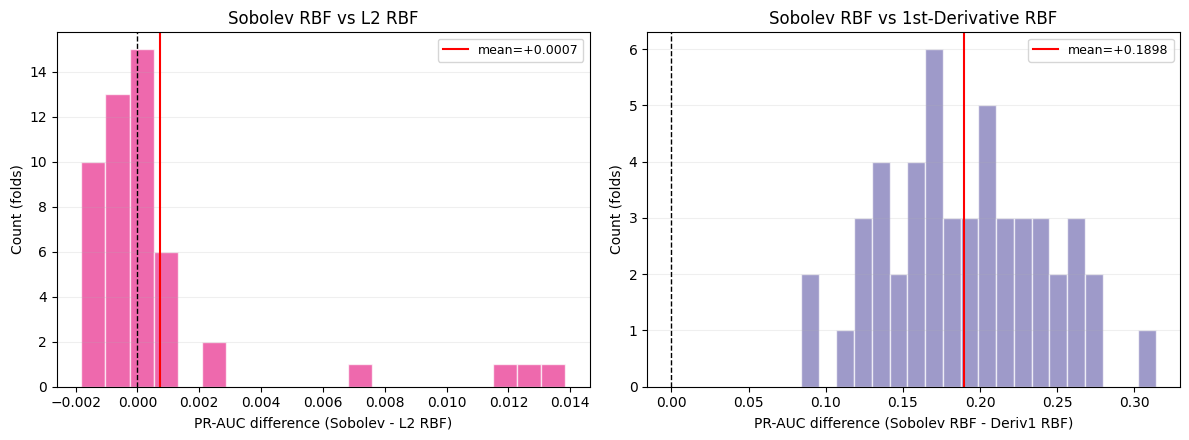


Sobolev vs L2 RBF: 21/50 folds Sobolev wins
Sobolev vs Deriv1: 50/50 folds Sobolev wins


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Sobolev vs L2 RBF
diff_sob_l2 = pivot["sobolev_rbf"].values - pivot["L2_rbf"].values
ax = axes[0]
ax.hist(diff_sob_l2, bins=20, color="#e7298a", edgecolor="white", alpha=0.7)
ax.axvline(0, color="black", ls="--", lw=1)
ax.axvline(diff_sob_l2.mean(), color="red", ls="-", lw=1.5, label=f"mean={diff_sob_l2.mean():+.4f}")
ax.set_xlabel("PR-AUC difference (Sobolev - L2 RBF)")
ax.set_ylabel("Count (folds)")
ax.set_title("Sobolev RBF vs L2 RBF")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis="y")

# Best kernel vs deriv1
best_kernel = "sobolev_rbf"
diff_best_deriv = pivot[best_kernel].values - pivot["deriv1_rbf"].values
ax = axes[1]
ax.hist(diff_best_deriv, bins=20, color="#7570b3", edgecolor="white", alpha=0.7)
ax.axvline(0, color="black", ls="--", lw=1)
ax.axvline(diff_best_deriv.mean(), color="red", ls="-", lw=1.5, label=f"mean={diff_best_deriv.mean():+.4f}")
ax.set_xlabel(f"PR-AUC difference ({KERNEL_LABELS[best_kernel]} - Deriv1 RBF)")
ax.set_ylabel("Count (folds)")
ax.set_title(f"{KERNEL_LABELS[best_kernel]} vs 1st-Derivative RBF")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis="y")

fig.tight_layout()
plt.show()

print(f"\nSobolev vs L2 RBF: {(diff_sob_l2 > 0).sum()}/{len(diff_sob_l2)} folds Sobolev wins")
print(f"Sobolev vs Deriv1: {(diff_best_deriv > 0).sum()}/{len(diff_best_deriv)} folds Sobolev wins")

## 8. Runtime analysis

In [20]:
print("Runtime per fold (seconds):\n")
for kname in KERNEL_ORDER:
    sub = df[df["kernel_name"] == kname]
    t = sub["time_seconds"]
    print(f"  {KERNEL_LABELS[kname]:22s}: {t.mean():.1f}s +/- {t.std():.1f}s  "
          f"(total: {t.sum()/60:.1f} min)")

print(f"\nTotal runtime: {df['time_seconds'].sum()/60:.1f} minutes")

Runtime per fold (seconds):

  L2 Linear             : 0.7s +/- 0.0s  (total: 0.6 min)
  L2 RBF                : 3.1s +/- 0.1s  (total: 2.6 min)
  1st-Derivative RBF    : 4.6s +/- 0.2s  (total: 3.9 min)
  Sobolev RBF           : 3.2s +/- 0.1s  (total: 2.7 min)

Total runtime: 9.6 minutes
